# Phishing Website Detection - Reproduction Study

This notebook reproduces and evaluates the GitHub project "URL-Based Phishing Detection Using Machine Learning".

The goal is to verify the author's findings, examine the dataset, evaluate the preprocessing steps, and reproduce the machine learning results.

In [2]:
import pandas as pd

df = pd.read_csv("phishing.csv")
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


## Data Loading and Initial Inspection

In [3]:
import pandas as pd

df = pd.read_csv("phishing.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11054, 32)


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


## Dataset Information

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (11054, 32)

Column Names:
['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class']

Data Types:
Index                  int64
UsingIP                int64
LongURL                int64
ShortURL               int64
Symbol@                int64
Redirecting//          int64
PrefixSuffix-          int64
SubDomains             int64
HTTPS                  int64
DomainRegLen           int64
Favicon                int64
NonStdPort             int64
HTTPSDomainURL         int64
RequestURL             int64
AnchorURL              int64
LinksInScriptTags  

### Dataset Structure Analysis

The dataset contains 11,054 observations and 32 columns. All features are stored as integer values, indicating that no additional encoding is required before model training.

The column named "Index" appears to function only as a row identifier rather than a meaningful cybersecurity feature. Since it does not contain predictive information about whether a website is phishing or legitimate, it should be removed before model training to avoid introducing unnecessary noise into the analysis.

In [5]:
df = df.drop("Index", axis=1)

print("Dataset Shape After Removing Index:", df.shape)

Dataset Shape After Removing Index: (11054, 31)


## Missing Values and Duplicate Records

This section checks whether the dataset contains missing values or duplicate rows before model training.

In [6]:
missing_values = df.isnull().sum()
missing_values

UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64

In [7]:
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 5205


In [8]:
print("Shape before removing duplicates:", df.shape)

df_no_dup = df.drop_duplicates()

print("Shape after removing duplicates:", df_no_dup.shape)

print("Duplicates removed:", df.shape[0] - df_no_dup.shape[0])

Shape before removing duplicates: (11054, 31)
Shape after removing duplicates: (5849, 31)
Duplicates removed: 5205


## Missing Values Analysis

In [9]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


## Duplicate Analysis

In [10]:
duplicates = df.duplicated().sum()

print("Dataset Shape Before Removing Duplicates:", df.shape)
print("Number of Duplicate Rows:", duplicates)

df_no_dup = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df_no_dup.shape)

Dataset Shape Before Removing Duplicates: (11054, 31)
Number of Duplicate Rows: 5205
Dataset Shape After Removing Duplicates: (5849, 31)


## Class Distribution Analysis

In [11]:
class_counts = df_no_dup['class'].value_counts()

print(class_counts)

class
-1    3019
 1    2830
Name: count, dtype: int64


In [12]:
class_percentages = df_no_dup['class'].value_counts(normalize=True) * 100

print(class_percentages)

class
-1    51.615661
 1    48.384339
Name: proportion, dtype: float64


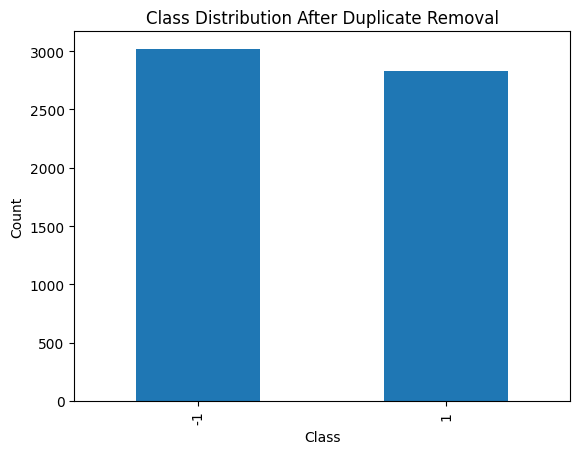

In [13]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')

plt.title("Class Distribution After Duplicate Removal")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Correlation Analysis

In [14]:
correlations = df_no_dup.corr()['class'].sort_values(ascending=False)

print(correlations)

class                  1.000000
HTTPS                  0.693228
AnchorURL              0.679125
PrefixSuffix-          0.381134
SubDomains             0.296214
WebsiteTraffic         0.281709
ServerFormHandler      0.281131
LinksInScriptTags      0.243864
RequestURL             0.237778
GoogleIndex            0.118217
StatsReport            0.108486
UsingIP                0.104952
LinksPointingToPage    0.068463
AgeofDomain            0.062800
LongURL                0.058228
PageRank               0.048140
Symbol@                0.034757
DNSRecording           0.033204
NonStdPort             0.014201
StatusBarCust          0.012790
DisableRightClick      0.009286
InfoEmail             -0.008014
IframeRedirection     -0.011756
UsingPopupWindow      -0.022455
Favicon               -0.025457
Redirecting//         -0.036693
WebsiteForwarding     -0.037462
HTTPSDomainURL        -0.051412
ShortURL              -0.076166
AbnormalURL           -0.090043
DomainRegLen          -0.218623
Name: cl

In [15]:
print(correlations.head(10))

class                1.000000
HTTPS                0.693228
AnchorURL            0.679125
PrefixSuffix-        0.381134
SubDomains           0.296214
WebsiteTraffic       0.281709
ServerFormHandler    0.281131
LinksInScriptTags    0.243864
RequestURL           0.237778
GoogleIndex          0.118217
Name: class, dtype: float64


## Top Feature Correlations

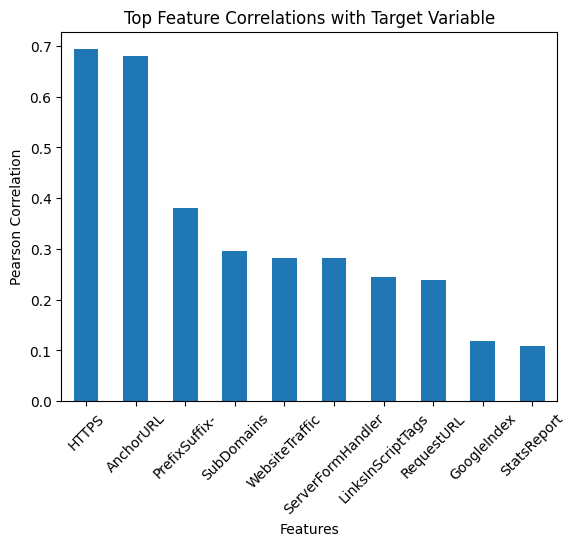

In [16]:
import matplotlib.pyplot as plt

top_features = correlations.drop('class').head(10)

top_features.plot(kind='bar')

plt.title("Top Feature Correlations with Target Variable")
plt.xlabel("Features")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45)

plt.show()

## Feature Distributions

In [17]:
df_no_dup.describe()

,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,Favicon,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
count,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,...,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000,5849.000000
mean,0.132843,-0.616003,0.720294,0.588648,0.718242,-0.760301,0.065823,0.149085,-0.305864,0.581809,...,0.564028,0.785604,0.021371,0.475124,0.233886,-0.423833,0.661823,0.347752,0.697042,-0.032313
std,0.991222,0.777323,0.693728,0.808459,0.695852,0.649627,0.802448,0.924473,0.952157,0.813395,...,0.825826,0.618782,0.999857,0.879994,0.826010,0.905818,0.749725,0.579027,0.717091,0.999563
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


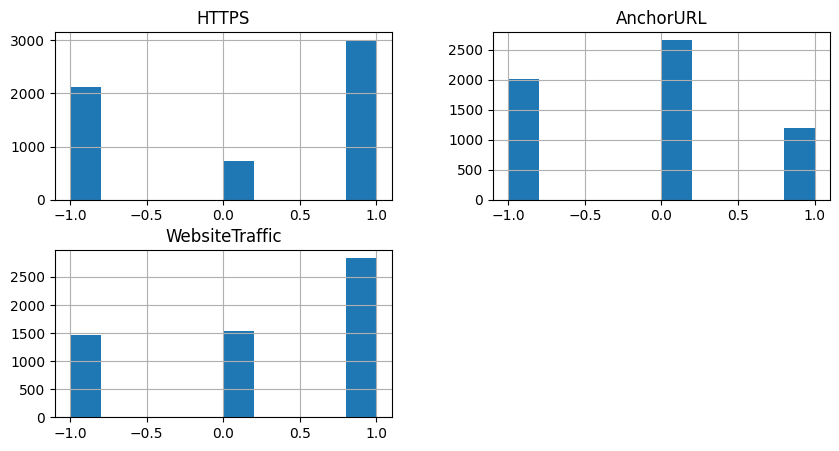

In [18]:
df_no_dup[['HTTPS', 'AnchorURL', 'WebsiteTraffic']].hist(figsize=(10,5))
plt.show()

## Feature Selection

In [19]:
columns_to_drop = [
    'LongURL',
    'ShortURL',
    'Symbol@',
    'Redirecting//',
    'DomainRegLen',
    'Favicon',
    'UsingPopupWindow',
    'IframeRedirection',
    'LinksPointingToPage'
]

df_selected = df_no_dup.drop(columns=columns_to_drop)

print("Shape before feature selection:", df_no_dup.shape)
print("Shape after feature selection:", df_selected.shape)
print("Remaining columns:")
print(df_selected.columns.tolist())

Shape before feature selection: (5849, 31)
Shape after feature selection: (5849, 22)
Remaining columns:
['UsingIP', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'StatsReport', 'class']


## Preparing Features and Target Variable

In [20]:
X = df_selected.drop('class', axis=1)
y = df_selected['class']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (5849, 21)
Target vector shape: (5849,)


## Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    scaled,
    columns=X.columns
)

print(X_scaled.shape)
X_scaled.head()

(5849, 21)


,UsingIP,PrefixSuffix-,SubDomains,HTTPS,NonStdPort,HTTPSDomainURL,RequestURL,AnchorURL,LinksInScriptTags,ServerFormHandler,...,AbnormalURL,WebsiteForwarding,StatusBarCust,DisableRightClick,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,StatsReport
0,0.874911,-0.369011,-0.082035,0.920511,0.438422,-2.184935,0.885618,0.190783,-1.108454,-0.550407,...,0.437867,-0.389656,0.400932,0.227157,-1.021604,-1.676432,-0.283176,-0.636128,0.451107,0.422518
1,0.874911,-0.369011,-1.328329,-1.243069,0.438422,-2.184935,0.885618,0.190783,-1.108454,-0.550407,...,-2.283797,-0.389656,0.400932,0.227157,0.978852,-1.676432,0.927567,-0.636128,0.451107,-2.366766
2,0.874911,-0.369011,-1.328329,-1.243069,0.438422,-2.184935,-1.129155,0.190783,0.190814,-0.550407,...,0.437867,-0.389656,0.400932,0.227157,-1.021604,-1.676432,0.927567,-0.636128,0.451107,0.422518
3,0.874911,-0.369011,1.164259,0.920511,0.438422,0.457680,0.885618,0.190783,0.190814,-0.550407,...,0.437867,-0.389656,-2.494191,0.227157,-1.021604,-1.676432,-0.283176,-0.636128,0.451107,0.422518
4,-1.142973,-0.369011,1.164259,0.920511,0.438422,-2.184935,0.885618,0.190783,0.190814,-0.550407,...,-2.283797,-0.389656,0.400932,0.227157,0.978852,0.596505,0.927567,-0.636128,0.451107,-2.366766


## Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4679, 21)
X_test : (1170, 21)
y_train: (4679,)
y_test : (1170,)


## Class Balancing with SMOTE

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("Training class distribution after SMOTE:")
print(y_train.value_counts())

Training class distribution after SMOTE:
class
-1    2388
 1    2388
Name: count, dtype: int64


## Gradient Boosting Classifier

In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9435897435897436

Confusion Matrix:
[[588  43]
 [ 23 516]]

Classification Report:
              precision    recall  f1-score   support

          -1       0.96      0.93      0.95       631
           1       0.92      0.96      0.94       539

    accuracy                           0.94      1170
   macro avg       0.94      0.94      0.94      1170
weighted avg       0.94      0.94      0.94      1170



## Model Comparison

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=30, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(max_depth=4, learning_rate=0.7, random_state=42),
    "Multi-Layer Perceptron": MLPClassifier(random_state=42),
    "Support Vector Machine": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([name, accuracy])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

c:\Users\97254\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy
5,Gradient Boosting,0.946154
4,Random Forest,0.939316
6,Multi-Layer Perceptron,0.939316
7,Support Vector Machine,0.938462
0,Logistic Regression,0.923932
3,Decision Tree,0.921368
1,K-Nearest Neighbors,0.917949
2,Naive Bayes,0.661538


## Best Model Evaluation (Gradient Boosting)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred, pos_label=1))
print("MCC:", matthews_corrcoef(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9435897435897436
Precision: 0.9230769230769231
Recall: 0.9573283858998145
F1 Score: 0.9398907103825137
MCC: 0.8873061705310061

Confusion Matrix:
[[588  43]
 [ 23 516]]


## ROC-AUC Evaluation

ROC-AUC: 0.9900090853226465


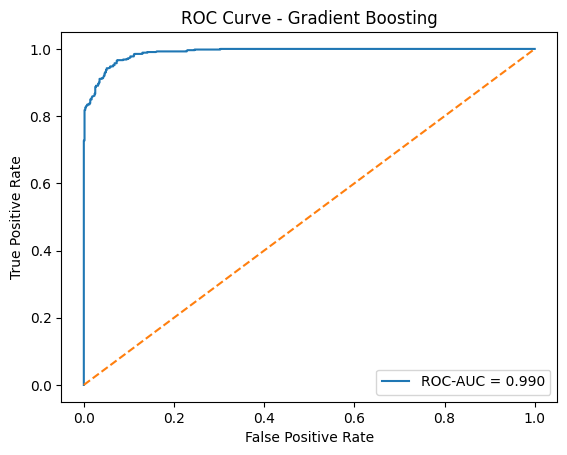

In [27]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = gb.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label=1)

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()